In [32]:
import importlib
import src.utils.syntetic_data_generation as sdg

In [33]:
import pandas as pd

idx_df, instr_df = sdg.generate_synthetic_ohlc(
    n_intervals=600, ticks_per_interval=10, time_interval="1min",  # "1T" = 1 minute
    target_corr=0.9, sigma_index=0.01, sigma_instr=0.015,
    start_time="2025-01-01 00:00:00", return_type="log")
print(idx_df.head(3))
print(instr_df.head(3))

            timestamp        open        high         low       close
0 2025-01-01 00:00:00   98.530296  100.728120   97.164384  100.362373
1 2025-01-01 00:01:00  100.495727  103.959099  100.495727  103.616228
2 2025-01-01 00:02:00  103.440506  107.772797  103.440506  106.862143
            timestamp        open        high         low       close
0 2025-01-01 00:00:00   98.589767  101.596238   96.798384  101.596238
1 2025-01-01 00:01:00  101.683353  107.603389  101.683353  105.995205
2 2025-01-01 00:02:00  106.257393  112.974363  106.257393  112.868444


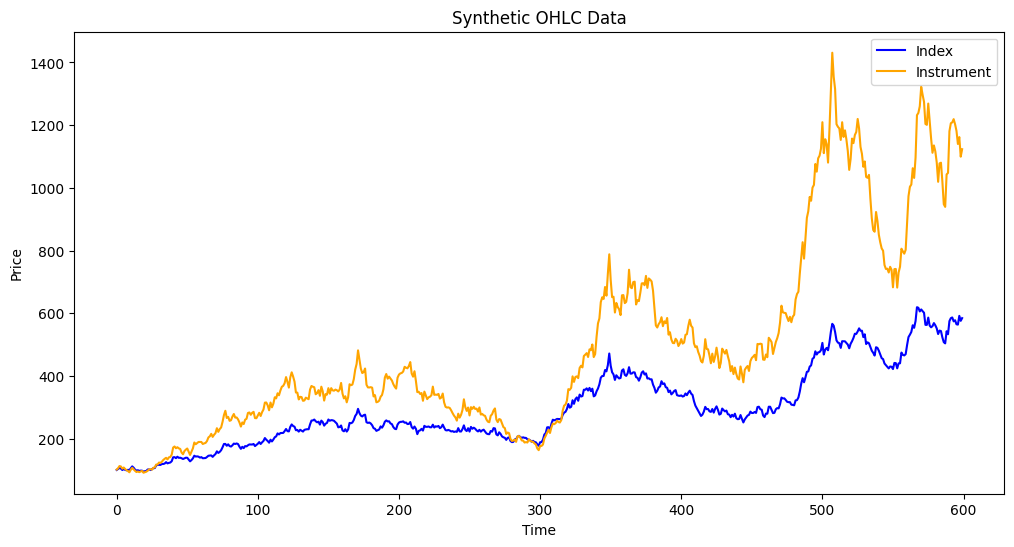

In [34]:
#plot close prices
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(idx_df['close'], label='Index', color='blue')
plt.plot(instr_df['close'], label='Instrument', color='orange')
plt.title('Synthetic OHLC Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [35]:
idx_df

,timestamp,open,high,low,close
0,2025-01-01 00:00:00,98.530296,100.728120,97.164384,100.362373
1,2025-01-01 00:01:00,100.495727,103.959099,100.495727,103.616228
2,2025-01-01 00:02:00,103.440506,107.772797,103.440506,106.862143
3,2025-01-01 00:03:00,105.173323,106.798614,104.075993,104.757069
4,2025-01-01 00:04:00,106.386639,106.386639,100.192093,100.192093
...,...,...,...,...,...
595,2025-01-01 09:55:00,580.852954,580.852954,560.408617,564.963934
596,2025-01-01 09:56:00,574.977383,578.931500,563.881938,563.881938
597,2025-01-01 09:57:00,569.537018,596.222068,569.537018,591.800079
598,2025-01-01 09:58:00,590.568408,590.568408,575.940866,575.940866


In [43]:
idx_df_low = sdg.aggregate_ohlc(idx_df, '1min')
idx_df_high =  sdg.aggregate_ohlc(idx_df_low, '1h')

ts = sdg.extract_time_series_per_interval(idx_df_high, idx_df_low, price_column='close', include_first_open=True)